# Tutorial 2: From Methylation Probability to Nucleosome Positioning Prediction
With the normalized methylation probabilities computed in the last tutorial ([Tutorial 1](./tut01_meth_prob.ipynb)), we are now ready to perform simulations to sample the nucleosome positions. As in Tutorial 1, we focus on the 601 fibers for illustration and brevity, and one can process R1 and R2 fibers with the exact same steps. Let us first reload the processed experimental HDF5 file:

In [1]:
from pathlib import Path
from catella.experiment.methdata import MethPrintExperiment

exp_h5 = Path("example/tut01_meth_prob/experiment/analysis.h5")
exp_data = MethPrintExperiment.load(exp_h5)

To start the simulations, we need to create a configuration file specifying the parameter values. The list of parameters required is as follows:

| Name          | Description
| ------------- | -----------------------------------------------------------------------------
| nucbp         | The amount of DNA (in bp) occupied by a bound nucleosome (e.g., 147 bp)
| llink         | Length (in bp) of the linker DNA
| elink         | Energy scale (in $k_BT$) of the linker DNA potential.
| mu            | Chemical potential (in units of $k_BT$). The energy associated with non-specific binding of nucleosome to DNA
| start_temp    | Start temperature
| end_temp      | End temperature
| cool_option   | How to adjust temperature over time. Options are "linear", "geometric", or "constant"
| nsweep        | Number of "sweeps" or timesteps in the simulation
| print_freq    | Frequency (in sweeps) at which to record simulation data
| emax          | The maximum energy cost allowed (in $k_BT$) from the methylation footprinting data

It may be difficult to determine an appropriate value for some of these parameters *a priori*. One of which is the starting temperature (`start_temp`). Setting it too low may prevent the system from exploring the full energy landscape and sampling space initially. `catella` provides a method `estimate_start_temp` to help with this estimation. This method returns a given percentile (default the 90th) of the magnitude of the sequence-specific energy landscape $|E_{\text{seq}}|$, estimated from a random subsample of molecules. Setting `start_temp` to approximately this value ensures that even large energy barriers in the data are readily crossable early in the annealing schedule, so the simulation does not freeze into its initial nucleosome configuration. Here we use a higher-than-default percentile (99th) for a firmer guarantee that even the rarest, most extreme barriers are crossable, at the cost of a hotter and slightly slower-to-mix start:

In [2]:
import catella
start_temp = catella.estimate_start_temp(exp_data, prob_name="meth_prob_model", percentile=99.0)
print(f"Estimated start temperature: {start_temp}")

Estimated start temperature: 22.060434403162414


Given this, we will set `start_temp = 22.0`. We pair this with `end_temp = 1.0`, the same $k_BT$ unit that `mu`, `elink`, and `emax` are already expressed in, so that the coldest state of the annealing schedule represents the model's actual equilibrium distribution rather than an artificially sharpened or flattened one. `start_temp` only needs to be high enough for the schedule to mix well early on, and it does not change what that final, converged distribution is, so it is fine (and expected) for different experiments or loci to need different `start_temp` values. Cooling below `end_temp = 1.0` (i.e., $\beta > 1$) would instead sample an artificially sharpened, over-confident version of the posterior, understating the true heterogeneity between simulation replicates; cooling only to a temperature above 1.0 would conversely flatten the posterior and overstate that heterogeneity. Since we want the replicate ensemble to reflect the model's actual uncertainty in nucleosome position, `end_temp = 1.0` is the correct choice rather than a free parameter to tune lower for a sharper-looking answer.

Another parameter that is difficult to estimate is the chemical potential $\mu$. Since the energy landscape can take both negative and positive values, a neutral starting choice for `mu` is 0. Alternatively, one could set $\mu$ so that it is equal to the median of the data energy landscape, i.e., $\mu = \text{median}(E_{\text{data}})$. This can be done by setting $\mu$ to an arbitrary number (say 0) in the parameter list, and then using the option `use_median_eseq_mu` in `catella.run`. We use `mu = 0.0` directly for this tutorial.

Additionally, we set `emax = 25.0`, chosen to sit just above our estimated `start_temp = 22.0`. If `emax` were set well below `start_temp`, the clamp would truncate the same large energy barriers that `start_temp` was calibrated to make crossable, undoing that calibration. We set `elink = 25.0` to match `emax`, so the steric repulsion is energetically comparable to the sequence-derived energy scale over a meaningful range as nucleosomes approach the `llink` boundary, not only in the last fraction of a bp before contact (which is already forbidden even at a much smaller `elink`, since the repulsion grows steeply at short range regardless). This keeps the physical packing preference and the data-driven preference on a similar energy footing.

We specify all the simulation parameters utilizing the `SimSettings` object:

In [3]:
from catella.simulation.engine import SimSettings

settings = SimSettings(
    nucbp=147,
    llink=50,
    elink=25.0,
    mu=0.0,
    start_temp=22.0,
    end_temp=1.0,
    cool_option="geometric",
    nsweep=20000,
    print_freq=100,
    emax=25.0)

One can also specify the parameters in a `json` or `yml` file. For example, in `.yml` format the file looks as follows:

In [4]:
!cat example/tut02_run_sim/simulation/sim_params.yml

nucbp:       147
llink:       50
elink:	     25.0
mu:          1.0
start_temp:  22.0
end_temp:    1.0
cool_option: "geometric"
nsweep:      20000
print_freq:  100
emax:        25.0

Next, we need to extract the methylation probabilities $p_M$ from the processed data and store them in a dictionary:

In [5]:
meth_prob = {"601": exp_data.analysis["601"]["meth_prob_model"]}

We now use the `catella.run` method to run the simulations. This method requires specifying the chromosomes (DNA segments) on which we would like to perform the sampling, the number of simulations to conduct per molecule (`nsim`), the simulation parameters (`settings`), and the methylation probability profile for each molecule in each chromosome (`meth_prob`). We also need to specify the output directory (`out_dir`) where the simulation results will be stored. The simulations can be run in parallel using multiple processes, and this is set via `nworker` (default is 1). By default, the `verbose` option is set to `True`, allowing a progress bar to be displayed in the terminal that provides an estimation of the time remaining before all jobs are complete.

In [6]:
sim_dir = Path("example/tut02_run_sim/simulation/result/") # Note that this dir must not exist beforehand
sim_data = catella.run(chroms="601",
                       nsim=5,
                       seed=2346,
                       meth_prob=meth_prob,
                       settings=settings,
                       out_dir=sim_dir,
                       nworker=20)

Output()

With `nworker=20`, the simulations should take around ten minutes to complete (on a modern MacBook Pro with an M4 chip). Each simulation generates an HDF5 file containing the output data as specified by the `out_types` option in `run`. The default value for this option is `all`, including all information about the system such as its energy and temperature over time as well as the nucleosome positions. All simulation HDF5 files are located within the sub-directory `raw_data` in `out_dir`. Additionally, an overall dataset HDF5 file containing the metadata of the simulations and the downstream analysis is created and stored in `out_dir/results.h5` by default. The name of this file can be changed via the `dataset_name` option in `run`.

<div class="alert alert-info">
    
**Note:** Sub-directories within `raw_data` should not be touched, as `catella` relies on the file structure there to access the raw simulation data.

</div>

## Analyzing the simulation results

We first inspect the raw simulation data to check that the results are reasonable before conducting any downstream analysis. To access the raw data from a specific simulation run (say run 0 for molecule 0), we use the `raw` property, which returns a `SimData` object:

In [7]:
sim_data.raw["601",0,0]

SimData(nucbp, nbp, llink, elink, mu, seed, time, energy, position, temp)

<div class="alert alert-info">
    
**Note:** All molecules and simulation runs are labelled using zero-based indexing.

</div>

<div class="alert alert-info">
    
**Note:** Accessing simulation properties such as `energy` and `temp` (for the system's temperature) always returns a view of the underlying `numpy` array that is non-writeable to preserve data integrity. The same applies to the property `position`, which returns a `Tuple` of non-writeable `numpy` arrays of the nucleosome positions over time.

</div>

A good sanity check that we have run the simulation for long enough and that the system has reached a steady state is to see whether the total energy has stabilized. We can plot the time series of the energy values as follows:

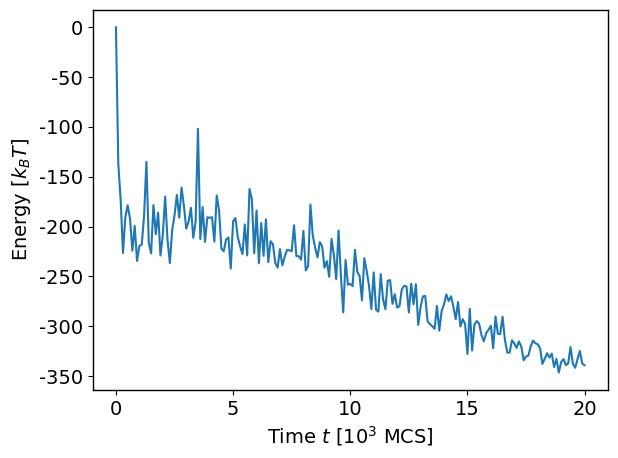

In [8]:
catella.plot_energy(sim_data, chrom="601", mol=0, run=0)

We can see that the energy dropped significantly at the beginning and then gradually decreased and stabilized at around $-350 k_BT$ over time (reported in units of MCS, or number of Monte Carlo sweeps).

Another way to see whether the system has stabilized is to plot the nucleosome positions over time as a heatmap. This can be done using the `catella.plot_nuc_pos` method, and it is useful to enable the `plot_eseq` option to show within the same plot the sequence-specific energy landscape $E_{\text{seq}}$ for the molecule derived from its methylation footprinting data.

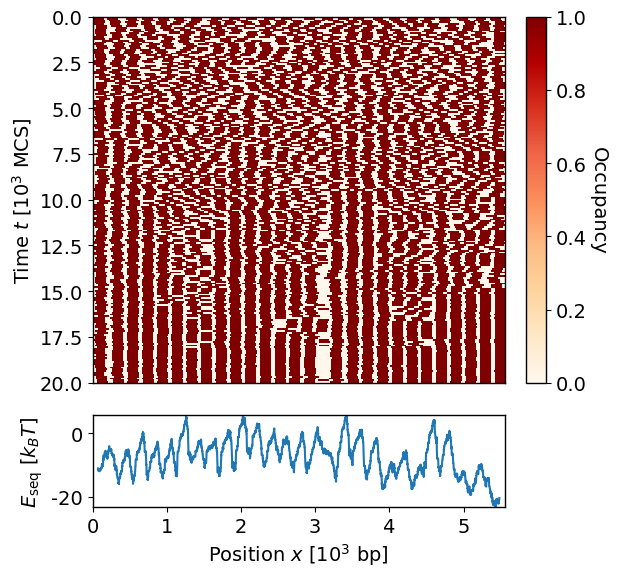

In [9]:
catella.plot_nuc_pos(sim_data, chrom="601", mol=0, run=0, plot_eseq=True)

The nucleosome locations are shown in yellow in this plot, and they behave as one would expect: as the temperature decreases, the extent of repositioning and shuffling reduces, and the nucleosomes freeze into a final set of positions. Also, comparing with the energy landscape $E_{\text{seq}}$, we see that the nucleosomes tend to avoid the maxima and sit near the minima as expected. 

To get a sense of the overall picture of nucleosome positioning across all molecules, we use `catella.analyze` to perform some basic quantification of the simulated nucleosome positions:

In [10]:
catella.analyze(sim_data)

This method computes the average number of nucleosomes (`mean_nnuc`) and the average nucleosome occupancy (`occup`) for each molecule. The latter is defined as
$$
O_i(x) = \frac{1}{N_{\text{sim}}}\sum_{n=1}^{N_{\text{sim}}}s_i^{(n)}(x) \;,
$$
where $s_i^{(n)} = 1$ if, in the $n$th simulation, a nucleosome occupies base-pair $x$ and $0$ otherwise.

These results are stored in `sim_data.analysis`. For instance, to retrieve the average number of nucleosomes in each 601 array fiber, we do the following:

In [11]:
sim_data.analysis["601"]["mean_nnuc"]

,0
0,27.0
1,22.6
2,25.2
3,27.4
4,13.6
...,...
95,25.8
96,28.0
97,27.4
98,28.0


To visualize the averaged nucleosome occupancy across all molecules, we sort the molecules by the similarity of their occupancy profiles, and then use the `catella.plot_occup` method to plot the heatmap. We again enable the `plot_eseq` option to see the correspondence between the nucleosome positions and the underlying energy landscape: 

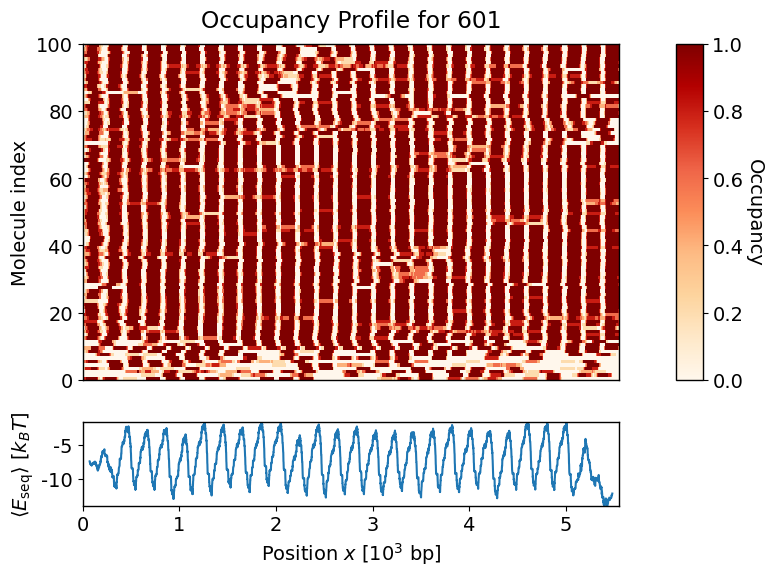

In [12]:
sorted_mat = catella.sort_by_linkage(dataset=sim_data, data_name="occup")
catella.plot_occup(sim_data, chrom="601", occup_name="occup_sorted", plot_eseq=True)

This heatmap agrees with our expectation that 601 arrays have highly regular nucleosome positions. The simulations again highlight a few molecules with low nucleosome occupancy, likely because histone octamer transfer was less successful for this subset of fibers. Finally, we can save our analyses of the simulation results (in the HDF5 file `out_dir/results.h5`) that can be retrieved later for further post-processing:

In [13]:
sim_data.save()